# GDP, Life Expectancy, and Time: A Cross-Country Analysis

This notebook investigates how the relationship between national wealth and population health has changed between 1952 and 2007 using the Gapminder dataset.

**Research question:** Does the relationship between GDP per capita and life expectancy differ between 1952 and 2007, and how do we communicate that finding clearly?

**Tools used:** Python, pandas, matplotlib, statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

plt.style.use("seaborn-v0_8-whitegrid")

gapminder = pd.read_csv("data/gapminder.csv")
print(f"Dataset loaded: {gapminder.shape[0]} rows, {gapminder.shape[1]} columns")
print(f"Years covered: {gapminder['year'].min()} to {gapminder['year'].max()}")
print(f"Countries: {gapminder['country'].nunique()}")

Dataset loaded: 1704 rows, 6 columns
Years covered: 1952 to 2007
Countries: 142


In [3]:
years = [1952, 2007]
gap_subset = gapminder[gapminder["year"].isin(years)].copy()
gap_subset["log_gdp"] = np.log(gap_subset["gdpPercap"])

gap_subset.groupby("year")[["lifeExp"]].describe().round(1)

lifeExp                                          
       count  mean   std   min   25%   50%   75%   max
year                                                  
1952   142.0  49.1  12.2  28.8  39.1  45.1  59.8  72.7
2007   142.0  67.0  12.1  39.6  57.2  71.9  76.4  82.6

## Key findings

### 1. Life expectancy has risen substantially across all continents

The summary statistics above show that global mean life expectancy increased from approximately 49 years in 1952 to 67 years in 2007 — a gain of 18 years. The minimum also rose from 29 to 40 years, suggesting broad-based improvement rather than gains concentrated in wealthy countries.

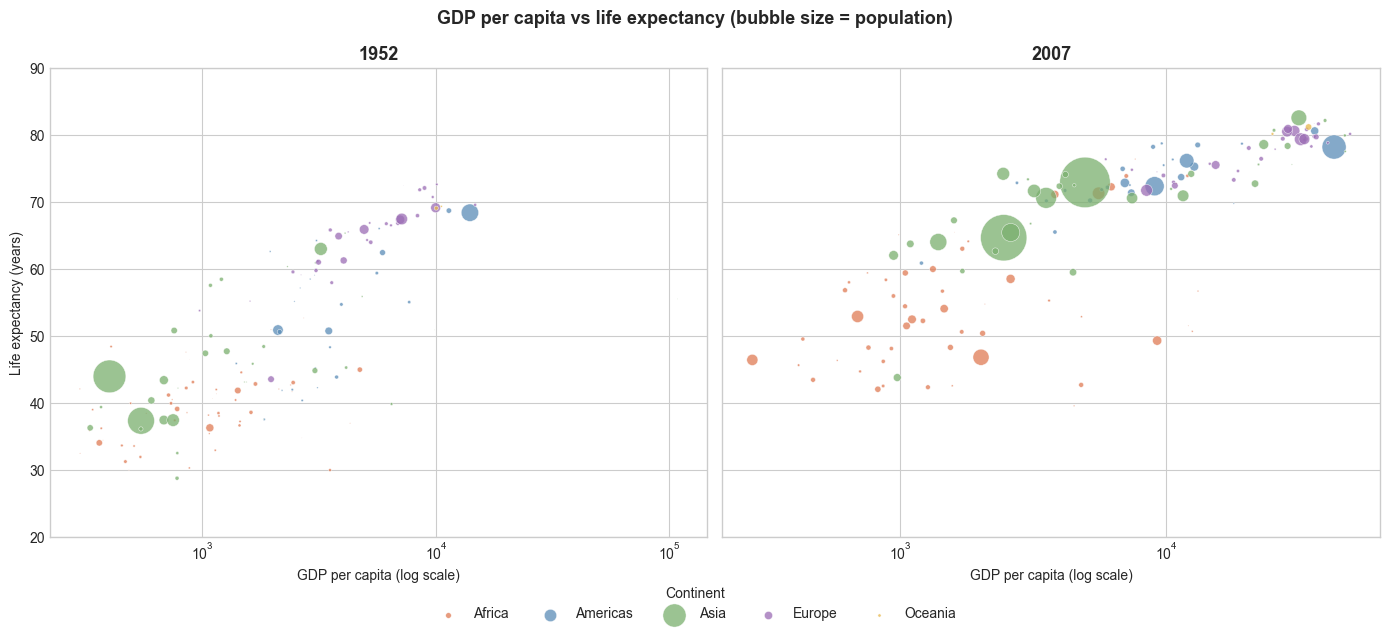

In [4]:
colours = {
    "Africa": "#E07B54",
    "Americas": "#5B8DB8",
    "Asia": "#7AAF6E",
    "Europe": "#9B6DB5",
    "Oceania": "#E8B84B",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, year in zip(axes, years):
    data = gap_subset[gap_subset["year"] == year]
    for continent, group in data.groupby("continent"):
        ax.scatter(
            group["gdpPercap"], group["lifeExp"],
            color=colours[continent], alpha=0.75,
            s=group["pop"] / 1e6, edgecolors="white",
            linewidths=0.4, label=continent,
        )
    ax.set_xscale("log")
    ax.set_xlabel("GDP per capita (log scale)", fontsize=10)
    ax.set_title(str(year), fontsize=13, fontweight="bold")
    ax.set_ylim(20, 90)

axes[0].set_ylabel("Life expectancy (years)", fontsize=10)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, title="Continent",
    loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.06),
)
fig.suptitle(
    "GDP per capita vs life expectancy (bubble size = population)",
    fontsize=13, fontweight="bold",
)

plt.tight_layout()
plt.show()

### 2. The relationship between GDP and life expectancy is log-linear

The scatter plots reveal a clear positive relationship between GDP per capita and life expectancy in both years. Using a log scale on the horizontal axis straightens the relationship, which motivates the use of log GDP as the predictor in our regressions below.

Two patterns stand out visually:

- By 2007, the cloud of points has shifted **upward** — countries at every income level live longer than their 1952 counterparts.
- African countries (orange) remain clustered at lower life expectancies in 2007, despite gains in GDP, suggesting that income alone does not fully explain health outcomes.

In [5]:
reg_results = []

for year in years:
    data = gap_subset[gap_subset["year"] == year]
    model = smf.ols("lifeExp ~ log_gdp", data=data).fit()

    reg_results.append({
        "Year": year,
        "Slope (log GDP)": round(model.params["log_gdp"], 3),
        "Intercept": round(model.params["Intercept"], 3),
        "R-squared": round(model.rsquared, 3),
        "N": int(model.nobs),
    })

reg_df = pd.DataFrame(reg_results)
reg_df

,Year,Slope (log GDP),Intercept,R-squared,N
0,1952,8.830,-17.846,0.559,142
1,2007,7.203,4.950,0.654,142


### 3. The slope has decreased over time

The OLS regression of life expectancy on log GDP per capita shows that the slope coefficient **decreased** from about 8.8 in 1952 to 7.2 in 2007. In practical terms, a doubling of GDP per capita in 2007 was associated with approximately 5.0 additional years of life expectancy $\left(7.2 \times \ln(2) \approx 5.0 \right)$, compared to about 6.1 years in 1952 $\left(8.8 \times \ln(2) \approx 6.1 \right)$.

This suggests that while income still matters for health outcomes, its marginal importance has weakened — likely because improvements in public health, medicine, and international aid have raised life expectancy even in lower-income countries.

The R-squared increased slightly, suggesting that GDP per capita became a somewhat stronger predictor of life expectancy over this period — though roughly a third of the variation remains unexplained by income alone.

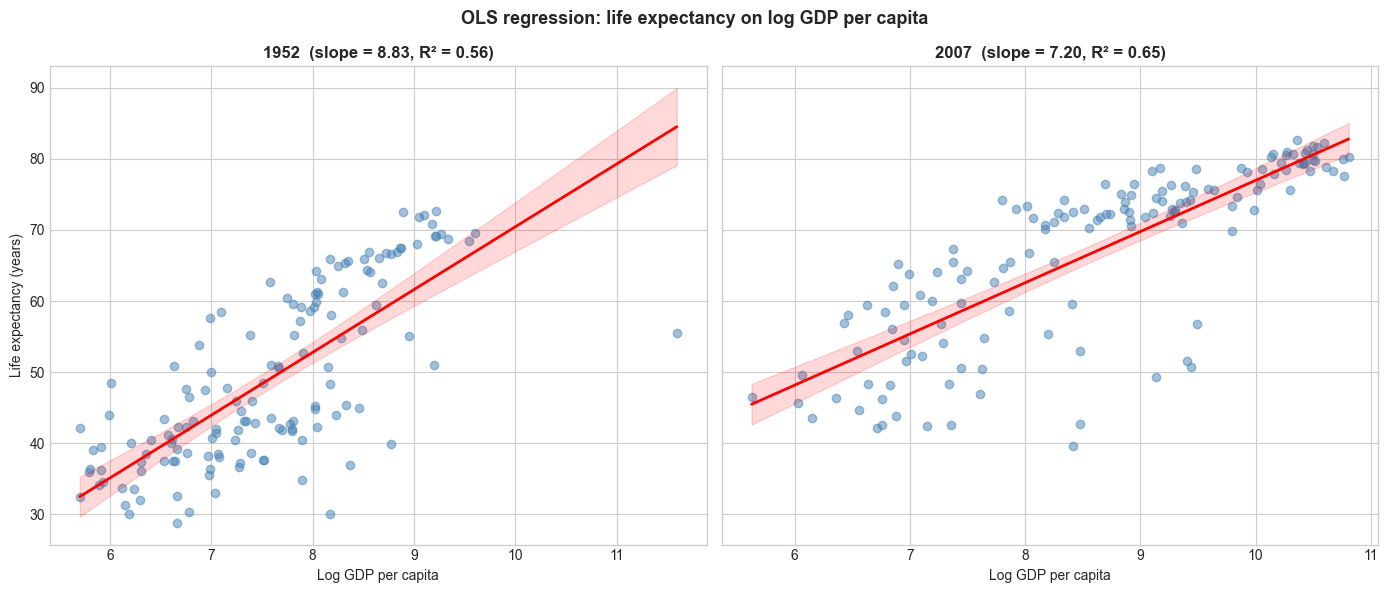

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, year in zip(axes, years):
    data = gap_subset[gap_subset["year"] == year]
    model = smf.ols("lifeExp ~ log_gdp", data=data).fit()

    # Observed data
    ax.scatter(data["log_gdp"], data["lifeExp"], alpha=0.5, color="steelblue")

    # Regression line with confidence interval
    grid = pd.DataFrame({"log_gdp": np.linspace(data["log_gdp"].min(), data["log_gdp"].max(), 100)})
    pred = model.get_prediction(grid).summary_frame(alpha=0.05)

    ax.plot(grid["log_gdp"], pred["mean"], color="red", linewidth=2)
    ax.fill_between(
        grid["log_gdp"], pred["mean_ci_lower"], pred["mean_ci_upper"],
        color="red", alpha=0.15,
    )

    ax.set_xlabel("Log GDP per capita", fontsize=10)
    ax.set_title(f"{year}  (slope = {model.params['log_gdp']:.2f}, R² = {model.rsquared:.2f})",
                 fontsize=12, fontweight="bold")

axes[0].set_ylabel("Life expectancy (years)", fontsize=10)

fig.suptitle("OLS regression: life expectancy on log GDP per capita",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

## Conclusion

The Gapminder data show that the positive relationship between national income and life expectancy has persisted over more than half a century, but has **weakened** somewhat. The flatter slope in 2007 suggests that factors beyond income — such as public health infrastructure, vaccination programmes, and international development efforts — have become relatively more important in explaining cross-country differences in life expectancy. Furthermore, the scatter plots also make clear that income is far from the whole story: countries with similar GDP per capita can differ by 20 or more years in life expectancy, particularly in Africa.

A natural next step would be to add continent as a control variable and examine whether the income–health gradient differs across regions. 